In [2]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

In [3]:
checkerboard = (7,6)

In [4]:
# Prepare object points
objp = np.zeros((checkerboard[0]*checkerboard[1],3), np.float32)
objp[:,:2] = np.mgrid[0:checkerboard[0],0:checkerboard[1]].T.reshape(-1,2)

In [5]:
objpoints = []
imgpoints = []

In [6]:
images = glob.glob('images/*.jpg')


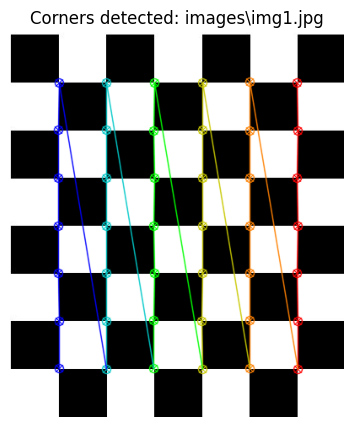

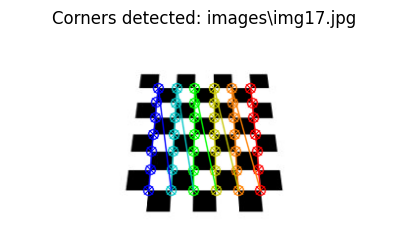

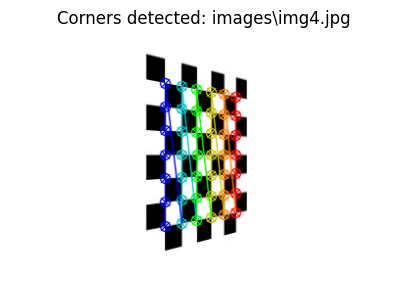

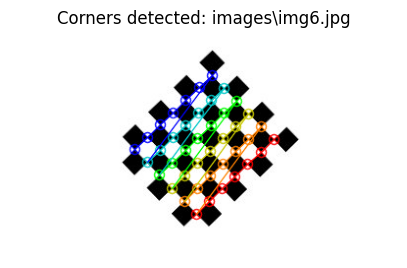

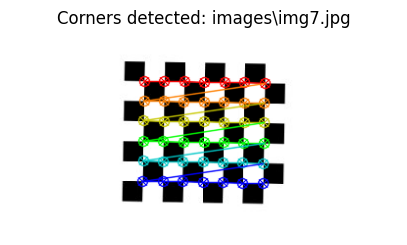

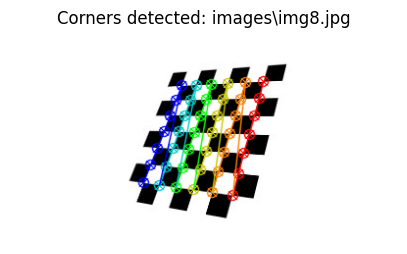

In [7]:
for fname in images:
    
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, checkerboard, None)

    if ret:
        objpoints.append(objp)
        imgpoints.append(corners)

        # Draw corners
        cv2.drawChessboardCorners(img, checkerboard, corners, ret)

        # Convert BGR → RGB for matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image in Jupyter
        plt.figure(figsize=(5,5))
        plt.imshow(img_rgb)
        plt.title(f"Corners detected: {fname}")
        plt.axis("off")
        plt.show()


In [8]:
# Perform calibration
if len(objpoints) > 0:

    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, gray.shape[::-1], None, None
    )

    print("Camera Matrix:\n", mtx)
    print("\nDistortion Coefficients:\n", dist)

else:
    print("No checkerboard corners detected!")

Camera Matrix:
 [[367.6316587    0.         194.8823746 ]
 [  0.         367.55758219 112.33267816]
 [  0.           0.           1.        ]]

Distortion Coefficients:
 [[-3.25086313e-02  7.07672108e-02 -6.26668619e-04 -8.50410841e-05
  -4.40475905e-02]]
